Smartphone ML Intelligence

## 01 — Data Audit and Cleaning

### Objectives

- Load the raw smartphone dataset
- Inspect rows, columns, data types, and missing values
- Detect duplicate and inconsistent records
- Standardize dates, text, and Boolean columns
- Create useful derived features
- Save a cleaned dataset for later machine learning experiments

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
df = pd.read_csv("../data/raw/Phones.csv")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 261
Columns: 42


In [4]:
df.head()

,name,brand,sale,processor_type,processor,fab,ram_type,rom_type,display_type,size,...,front,front_video,colors,antutu,geekbench_single,geekbench_multiple,speaker,wireless_charging,ip_rating,price
0,CMF Phone 1,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.67,...,16.0,"4, 30",3,646635,1013,2949,Mono,0,52,16000
1,CMF Phone 2 Pro,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.77,...,16.0,"4, 30",4,704101,1013,2936,Mono,0,54,19000
2,Galaxy A07,Samsung,Offline,Mediatek,Dimensity 6300,6,LPDDR4X,UFS 2.2,IPS LCD,6.70,...,8.0,"1, 30",2,450401,731,2012,Mono,0,54,16000
3,Galaxy A17,Samsung,Offline,Exynos,1330,5,LPDDR4X,UFS 2.2,Amoled,6.70,...,13.0,"1, 30",3,473905,942,2137,Mono,0,54,19000
4,Galaxy A27,Samsung,Offline,Snapdragon,6 Gen 3,4,LPDDR5X,UFS 3.1,Amoled,6.70,...,12.0,"1, 30",3,892500,1080,3192,Mono,0,64,32000


In [5]:
## Dataset overview

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 42 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  261 non-null    object 
 1   brand                 261 non-null    object 
 2   sale                  261 non-null    object 
 3   processor_type        261 non-null    object 
 4   processor             261 non-null    object 
 5   fab                   261 non-null    int64  
 6   ram_type              261 non-null    object 
 7   rom_type              261 non-null    object 
 8   display_type          261 non-null    object 
 9   size                  261 non-null    float64
 10  curved_display        261 non-null    int64  
 11  refresh_rate          261 non-null    int64  
 12  hbm                   235 non-null    float64
 13  protection            200 non-null    object 
 14  ppi                   261 non-null    int64  
 15  battery               2

In [6]:
schema_audit = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values
})

schema_audit

,column,dtype,non_null_count,missing_count,missing_percentage,unique_values
0,name,object,261,0,0.00,261
1,brand,object,261,0,0.00,14
2,sale,object,261,0,0.00,4
3,processor_type,object,261,0,0.00,6
4,processor,object,261,0,0.00,74
5,fab,int64,261,0,0.00,5
6,ram_type,object,261,0,0.00,3
7,rom_type,object,261,0,0.00,5
8,display_type,object,261,0,0.00,2
9,size,float64,261,0,0.00,29


In [7]:
## Missing-value analysis

missing_values = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

missing_values = (
    missing_values
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

missing_values

,missing_count,missing_percentage
fourth,255,97.70
fourth_mp,255,97.70
ultrawide,84,32.18
camera_sensor_name,84,32.18
third_mp,80,30.65
third,79,30.27
protection,61,23.37
hbm,26,9.96


In [8]:
## Categorical-value inspection

categorical_columns = [
    "sale",
    "processor_type",
    "ram_type",
    "rom_type",
    "display_type",
    "back_material",
    "frame_material",
    "speaker"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


sale
sale
Online      102
Offline      57
Both         55
Flagship     47
Name: count, dtype: int64

processor_type
processor_type
Mediatek        114
Snapdragon      102
Exynos           15
Apple Bionic     14
Unisoc            8
Tensor            8
Name: count, dtype: int64

ram_type
ram_type
LPDDR4X    128
LPDDR5X    109
LPDDR5      24
Name: count, dtype: int64

rom_type
rom_type
UFS 2.2    108
UFS 3.1     67
UFS 4.0     41
UFS 4.1     31
NVMe        14
Name: count, dtype: int64

display_type
display_type
Amoled     209
IPS LCD     52
Name: count, dtype: int64

back_material
back_material
Plastic      133
Glass        108
Leather       18
Aluminium      2
Name: count, dtype: int64

frame_material
frame_material
Plastic      168
Aluminium     86
Titanium       7
Name: count, dtype: int64

speaker
speaker
Stereo    209
Mono       52
Name: count, dtype: int64


In [9]:
## Numeric-value inspection

numeric_columns = df.select_dtypes(
    include=np.number
).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
fab,261.0,4.229885e+00,1.038132,2.00,4.00,4.00,4.00,6.0
size,261.0,6.687625e+00,0.170996,6.10,6.67,6.72,6.78,7.0
curved_display,261.0,2.068966e-01,0.405859,0.00,0.00,0.00,0.00,1.0
refresh_rate,261.0,1.234253e+02,15.255994,60.00,120.00,120.00,120.00,165.0
hbm,235.0,1.357574e+03,436.803988,450.00,1050.00,1300.00,1600.00,3600.0
ppi,261.0,4.072720e+02,68.564279,254.00,388.00,429.00,453.00,516.0
battery,261.0,5.948506e+03,1145.897356,3036.00,5000.00,6000.00,7000.00,10001.0
charging_speed,261.0,5.995402e+01,29.725374,15.00,33.00,45.00,80.00,125.0
thickness,261.0,8.085632e+00,0.539974,5.60,7.80,8.10,8.40,9.2
weight,261.0,1.986552e+02,15.454520,156.00,189.00,199.00,210.00,237.0


In [10]:
# Renaming Values in a format 

phones = df.copy()
phones.columns = (
    phones.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

text_columns = phones.select_dtypes(
    include="object"
).columns

text_columns

for column in text_columns:
    phones[column] = (
        phones[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

In [11]:
# Restructuring Date Format

phones["launch_date"] = pd.to_datetime(
    phones["launch_date"],
    format="%d-%m-%Y",
    errors="coerce"
)

phones[["name", "launch_date"]].head()

,name,launch_date
0,CMF Phone 1,2024-07-08
1,CMF Phone 2 Pro,2025-05-28
2,Galaxy A07,2026-02-05
3,Galaxy A17,2025-08-29
4,Galaxy A27,2026-06-25


In [12]:
# Converting binary fields to Boolean values

phones["curved_display"].value_counts(dropna=False)
phones["wireless_charging"].value_counts(dropna=False)

binary_mapping = {
    0: False,
    1: True
}

for column in [
    "curved_display",
    "wireless_charging"
]:
    phones[column] = (
        phones[column]
        .map(binary_mapping)
        .astype("boolean")
    )


In [13]:
# Camera-presence indicators

phones["has_ultrawide"] = phones["ultrawide"].notna()
phones["has_third_camera"] = phones["third"].notna()
phones["has_fourth_camera"] = phones["fourth"].notna()

phones[
    [
        "has_ultrawide",
        "has_third_camera",
        "has_fourth_camera"
    ]
].mean()

has_ultrawide        0.678161
has_third_camera     0.697318
has_fourth_camera    0.022989
dtype: float64

In [14]:
# Launch Year & Phone Age

phones["launch_year"] = (
    phones["launch_date"]
    .dt.year
    .astype("Int64")
)

REFERENCE_DATE = pd.Timestamp.today()

phones["phone_age_days"] = (
    REFERENCE_DATE
    - phones["launch_date"]
).dt.days

phones[
    [
        "name",
        "launch_date",
        "launch_year",
        "phone_age_days"
    ]
].head()


,name,launch_date,launch_year,phone_age_days
0,CMF Phone 1,2024-07-08,2024,774
1,CMF Phone 2 Pro,2025-05-28,2025,450
2,Galaxy A07,2026-02-05,2026,197
3,Galaxy A17,2025-08-29,2025,357
4,Galaxy A27,2026-06-25,2026,57


In [15]:
# Validating the Cleaned Data

assert phones.shape[0] == df.shape[0], (
    "Cleaning unexpectedly changed the row count."
)

assert phones["launch_date"].notna().all(), (
    "Some launch dates could not be parsed."
)

assert not phones.duplicated(
    subset=["brand", "name"]
).any(), (
    "Duplicate phones remain."
)

assert phones["price"].gt(0).all(), (
    "All prices must be positive."
)

assert phones["antutu"].gt(0).all(), (
    "All Antutu scores must be positive."
)

assert (
    phones["useful_camera_number"]
    <= phones["camera_number"]
).all(), (
    "Useful camera count exceeds total camera count."
)

assert not (
    phones["launch_date"] > REFERENCE_DATE
).any(), (
    "A launch date occurs after the reference date."
)

print("All validation checks passed.")

All validation checks passed.


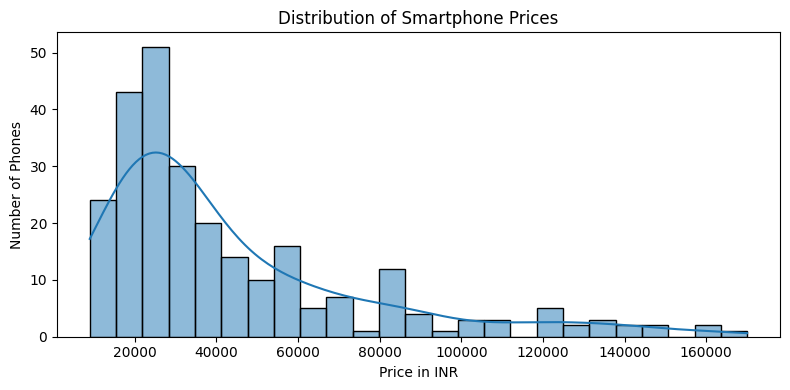

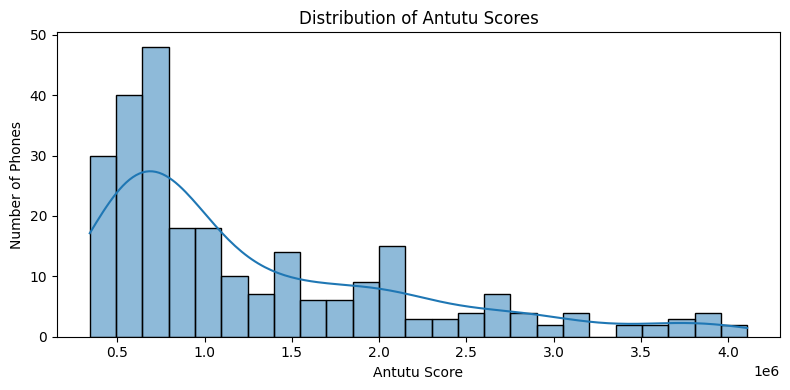

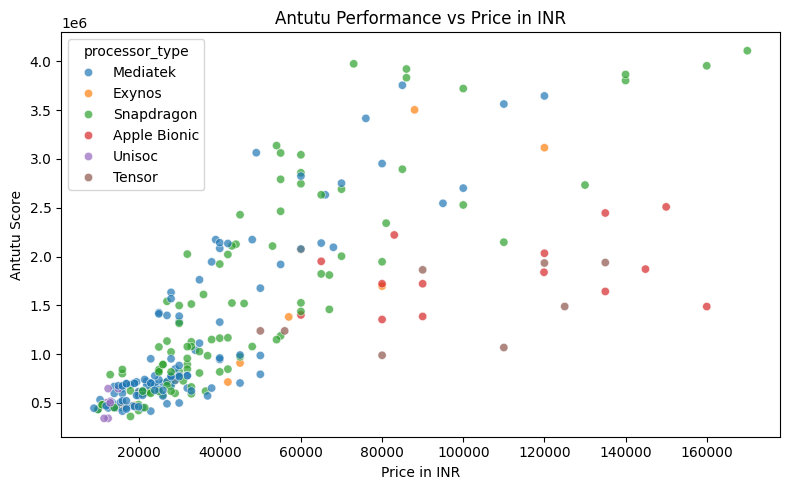

In [16]:
# Visualisations

##  Price distribution

plt.figure(figsize=(8, 4))

sns.histplot(
    data=phones,
    x="price",
    bins=25,
    kde=True
)

plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price in INR")
plt.ylabel("Number of Phones")
plt.tight_layout()
plt.show()


## Antutu distribution

plt.figure(figsize=(8, 4))

sns.histplot(
    data=phones,
    x="antutu",
    bins=25,
    kde=True
)

plt.title("Distribution of Antutu Scores")
plt.xlabel("Antutu Score")
plt.ylabel("Number of Phones")
plt.tight_layout()
plt.show()


## Price versus performance

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=phones,
    x="price",
    y="antutu",
    hue="processor_type",
    alpha=0.7
)

plt.title("Antutu Performance vs Price in INR")
plt.xlabel("Price in INR")
plt.ylabel("Antutu Score")
plt.tight_layout()
plt.show()


In [17]:
# Saving the CLEANED DATASET

PROCESSED_DATA_DIR = Path("../data/processed")
PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLEAN_DATA_PATH = (
    PROCESSED_DATA_DIR
    / "phones_clean.csv"
)

phones.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print("Cleaned dataset saved to:")
print(CLEAN_DATA_PATH.resolve())

Cleaned dataset saved to:
C:\Users\Rasik\smartphone-ml-intelligence\data\processed\phones_clean.csv


## Audit conclusions

- The dataset contains more than 260 smartphone records.
- No duplicate brand-model combinations were detected.
- Missing values are concentrated in optional camera and specification fields.
- Optional-camera absence and genuinely unknown values must be handled separately.
- Launch dates, Boolean fields, and text values were standardized.
- No global imputation or categorical encoding was performed to avoid data leakage.
- The cleaned dataset was saved for later EDA and machine learning experiments.

## Next step

Notebook `02_exploratory_data_analysis.ipynb` will examine:

- brand and market composition
- smartphone price segments
- price and benchmark distributions
- hardware relationships
- brand positioning
- possible outliers